# Fraud Detection: EDA, Outlier Analysis & DBSCAN Anomaly Detection
**Assignment 2** &nbsp;|&nbsp; **Dataset:** `Fraud Detection Dataset.csv` (51,000 transactions, 12 columns) &nbsp;|&nbsp; **Target:** `Fraudulent` (1 = fraud, 0 = genuine)



> Each section follows the same pattern: a short goal, the code (as a small function plus one call), and a note on what the output shows. Keep the CSV in the same folder as the notebook.

## 1. Setup
Imports, global settings and the parameters used later defined in one place.

In [7]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np  # noqa: F401  (kept because numeric helpers may be added later)
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------------------------------------------
# Global settings
# --------------------------------------------------------------------------------------
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
SHOW_PLOTS = True

# Ensure Google Drive locations are listed here so they are searched
DATA_CANDIDATES = [
    "Fraud Detection Dataset.csv",
    "Fraud_Detection_Dataset.csv",
    "/content/drive/MyDrive/Fraud Detection Dataset.csv",
    "/content/drive/MyDrive/Fraud_Detection_Dataset.csv"
]

CATEGORICAL_COLUMNS = ["Transaction_Type", "Device_Used", "Location", "Payment_Method"]
NUMERIC_SUMMARY_COLUMNS = ["Transaction_Amount", "Time_of_Transaction", "Account_Age",
                           "Number_of_Transactions_Last_24H"]

# Feature sets and DBSCAN settings (eps = neighbourhood radius, min_samples = points needed for a dense core)
BASE_FEATURES = ["Transaction_Amount", "Previous_Fraudulent_Transactions",
                 "Account_Age", "Number_of_Transactions_Last_24H"]
BASE_EPS, BASE_MIN_SAMPLES = 0.8, 15

ALT_FEATURES = ["Transaction_Amount", "Time_of_Transaction", "Previous_Fraudulent_Transactions",
                "Account_Age", "Number_of_Transactions_Last_24H"]
ALT_EPS, ALT_MIN_SAMPLES = 0.9, 20

# Keeps the DataFrame preview short, like a narrow notebook cell (affects print(df.head()) only)
pd.set_option("display.max_columns", 4)

print("Environment initialized successfully with Drive paths.")

Environment initialized successfully with Drive paths.


### Helper functions
Small reusable tools: showing a plot, loading the CSV,
computing IQR fences,
selecting rows outside them, and running DBSCAN (fill gaps with the median → standardise → cluster; label `-1` = anomaly).

In [8]:
def show_plot():
    """Display the current figure (or close it silently when SHOW_PLOTS is False)."""
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close("all")


def load_data():
    """Read the CSV, trying each accepted file name."""
    path = next((f for f in DATA_CANDIDATES if Path(f).exists()), DATA_CANDIDATES[0])
    return pd.read_csv(path)


def iqr_bounds(series):
    """Return (Q1, Q3, lower fence, upper fence) using the 1.5 x IQR rule."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    spread = q3 - q1
    return q1, q3, q1 - 1.5 * spread, q3 + 1.5 * spread


def rows_outside(data, column, lower, upper):
    """Rows whose value in `column` falls below `lower` or above `upper`."""
    return data[(data[column] < lower) | (data[column] > upper)]


def run_dbscan(data, feature_list, eps, min_samples):
    """
    Fill gaps with the median, standardise, run DBSCAN and return a copy of `data`
    with an extra `Cluster` column (-1 marks noise points, i.e. anomalies).
    """
    result = data.copy()
    for column in feature_list:
        result[column] = result[column].fillna(result[column].median())

    scaled = StandardScaler().fit_transform(result[feature_list])
    result["Cluster"] = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(scaled)
    return result

## 2. Loading & Data Quality Checks
We load the data and look at its size, columns, missing values and exact duplicates.

In [13]:
import os
from google.colab import drive

def check_data_quality(df):
    print("Dataset Shape:", df.shape)

    print("Columns List:")
    print(df.columns.tolist())

    # How many rows survive if every row with any missing value is dropped?
    print("Shape after dropping missing rows:", df.dropna().shape)

    print("--- Missing Percentage per Column ---")
    print(df.isnull().mean() * 100)

    print("Total Exact Duplicate Records:", df.duplicated().sum())

# Try loading the data; mount drive if local paths don't exist
try:
    df = load_data()
except FileNotFoundError:
    print("Dataset not found locally. Attempting to mount Google Drive...")
    drive.mount('/content/drive')
    df = load_data()

check_data_quality(df)

Dataset Shape: (51000, 12)
Columns List:
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']
Shape after dropping missing rows: (39583, 12)
--- Missing Percentage per Column ---
Transaction_ID                      0.000000
User_ID                             0.000000
Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
dtype: float64
Total Exact Duplicate Records: 881


**What we see:** 51,000 rows × 12 columns. About 5% of `Transaction_Amount`, `Time_of_Transaction`, `Device_Used`, `Location` and `Payment_Method` are missing, so dropping every incomplete row would leave only **39,583** rows – imputing is the better choice. There are **881** exact duplicate rows.

## 3. Task 1 – Column-wise Duplicate Count
For each column: non-null values, unique values, and how many entries are repeats (`non-null − unique`).

--- Column-wise Duplicate Count Table ---
                          Column  Total Non-Null  Unique Values  Duplicate Entries  Duplicate %
                  Transaction_ID           51000          50000               1000         1.96
                         User_ID           51000           4000              47000        92.16
              Transaction_Amount           48480          44821               3659         7.55
                Transaction_Type           51000              5              50995        99.99
             Time_of_Transaction           48448             24              48424        99.95
                     Device_Used           48527              4              48523        99.99
                        Location           48453              8              48445        99.98
Previous_Fraudulent_Transactions           51000              5              50995        99.99
                     Account_Age           51000            119              50881        99.7

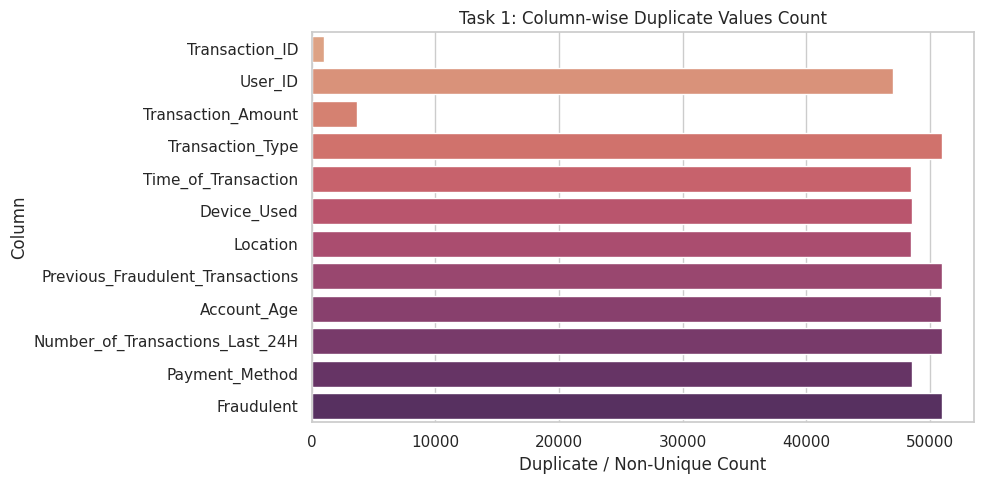

In [14]:
def column_duplicate_table(df):
    """For each column: non-null count, unique count and how many entries are repeats."""
    rows = []
    for column in df.columns:
        non_null = len(df[column].dropna())
        unique = df[column].nunique(dropna=True)
        repeated = non_null - unique
        rows.append({
            "Column": column,
            "Total Non-Null": non_null,
            "Unique Values": unique,
            "Duplicate Entries": repeated,
            "Duplicate %": round((repeated / non_null) * 100, 2) if non_null > 0 else 0,
        })
    return pd.DataFrame(rows)


def task1_column_duplicates(df):
    table = column_duplicate_table(df)
    print("--- Column-wise Duplicate Count Table ---")
    print(table.to_string(index=False))

    plt.figure(figsize=(10, 5))
    sns.barplot(data=table, x="Duplicate Entries", y="Column", palette="flare")
    plt.title("Task 1: Column-wise Duplicate Values Count")
    plt.xlabel("Duplicate / Non-Unique Count")
    plt.tight_layout()
    show_plot()


task1_column_duplicates(df)

**What we see:** low-cardinality columns  naturally show ~99.9% repeats, which is expected. The one surprise is `Transaction_ID`: **1,000 repeated IDs** although an ID should be unique – worth investigating.

## 4. Visual EDA
Class balance of the target and the shape of the amount distribution.

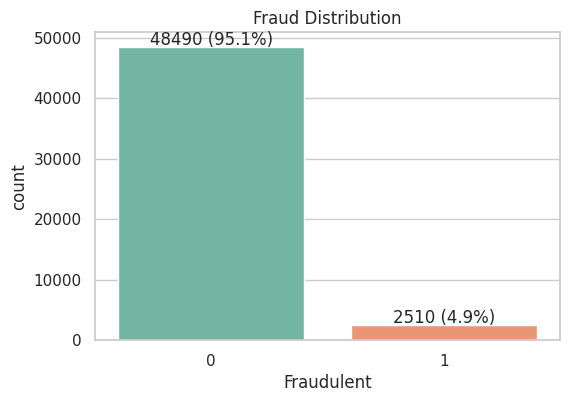

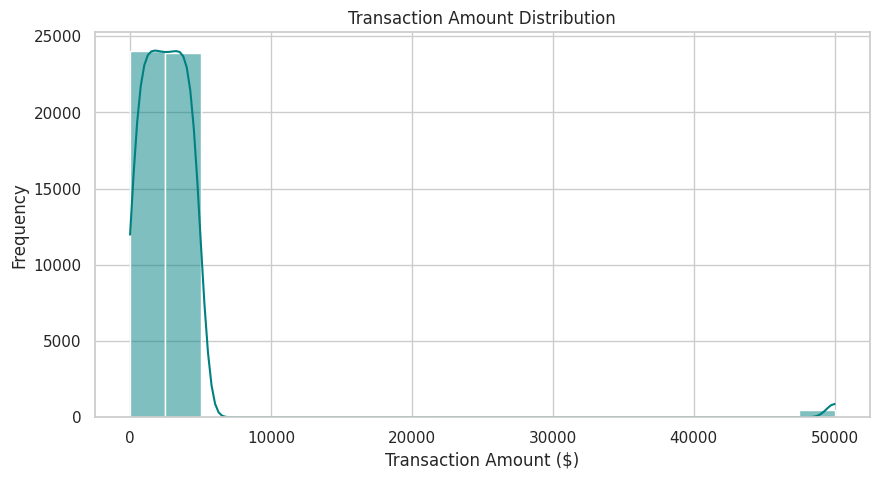

In [15]:
def plot_fraud_distribution(df):
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(x="Fraudulent", data=df, palette="Set2")
    plt.title("Fraud Distribution")

    # Label each bar with its count and share of all rows
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(f"{int(height)} ({height / len(df) * 100:.1f}%)",
                    (bar.get_x() + bar.get_width() / 2.0, height),
                    ha="center", va="center", xytext=(0, 5), textcoords="offset points")
    show_plot()


def plot_amount_distribution(df):
    plt.figure(figsize=(10, 5))
    sns.histplot(df["Transaction_Amount"], bins=20, kde=True, color="teal")
    plt.title("Transaction Amount Distribution")
    plt.xlabel("Transaction Amount ($)")
    plt.ylabel("Frequency")
    show_plot()


plot_fraud_distribution(df)
plot_amount_distribution(df)

**What we see:** fraud is rare (**2,510 of 51,000, about 4.9%**), and the amounts are spread widely with a long right tail.

## 5. Task 2A – Payment Method vs Fraud
Missing methods are kept as their own **Missing** group. We compare fraud rates per method and test independence with a chi-square test.

--- Crosstab: Payment Method vs Fraudulent ---
Fraudulent          0     1    All
Payment_Method                    
Credit Card     11072   574  11646
Debit Card      11230   572  11802
Invalid Method   1457    73   1530
Missing          2364   105   2469
Net Banking     11092   574  11666
UPI             11275   612  11887
All             48490  2510  51000

--- Fraud Percentage (%) per Payment Method ---
Fraudulent              0         1
Payment_Method                     
Credit Card     95.071269  4.928731
Debit Card      95.153364  4.846636
Invalid Method  95.228758  4.771242
Missing         95.747266  4.252734
Net Banking     95.079719  4.920281
UPI             94.851518  5.148482


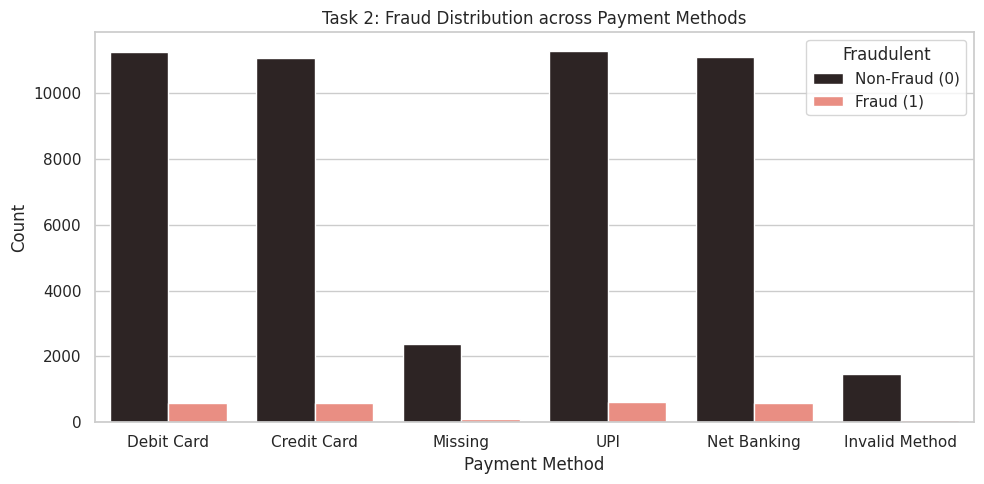

Chi-Square Independence Test (Payment Method vs Fraud): Stat = 3.885, p-val = 5.6607e-01


In [16]:
def task2a_payment_vs_fraud(df):
    data = df.copy()
    data["Payment_Method"] = data["Payment_Method"].fillna("Missing")   # keep rows with no method as own group

    counts = pd.crosstab(data["Payment_Method"], data["Fraudulent"], margins=True)
    print("--- Crosstab: Payment Method vs Fraudulent ---")
    print(counts)

    row_percent = pd.crosstab(data["Payment_Method"], data["Fraudulent"], normalize="index") * 100
    print("\n--- Fraud Percentage (%) per Payment Method ---")
    print(row_percent)

    plt.figure(figsize=(10, 5))
    sns.countplot(data=data, x="Payment_Method", hue="Fraudulent", palette="dark:salmon")
    plt.title("Task 2: Fraud Distribution across Payment Methods")
    plt.xlabel("Payment Method")
    plt.ylabel("Count")
    plt.legend(title="Fraudulent", labels=["Non-Fraud (0)", "Fraud (1)"])
    plt.tight_layout()
    show_plot()

    # Chi-square test of independence (margins excluded)
    statistic, p_value, _dof, _expected = chi2_contingency(
        pd.crosstab(data["Payment_Method"], data["Fraudulent"])
    )
    print(f"Chi-Square Independence Test (Payment Method vs Fraud): "
          f"Stat = {statistic:.3f}, p-val = {p_value:.4e}")


task2a_payment_vs_fraud(df)

**What we see:** fraud share is similar for every method (4.3%–5.1%) and the chi-square test gives **p = 0.57**, so there is **no significant link** between payment method and fraud.

## 6. Correlation Heatmap
Linear relationships between all numeric columns.

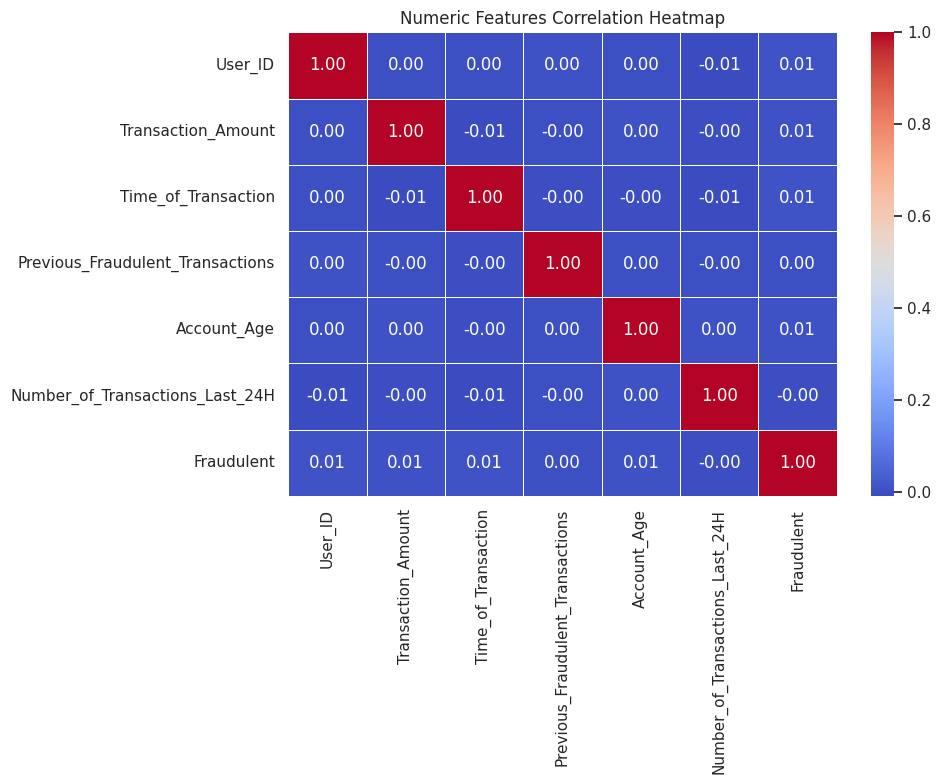

In [17]:
def plot_correlation_heatmap(df):
    numeric_only = df.select_dtypes(include="number")
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_only.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Numeric Features Correlation Heatmap")
    plt.tight_layout()
    show_plot()


plot_correlation_heatmap(df)

## 7. Outlier Analysis (IQR Rule)
A value is an outlier if it lies more than 1.5 × IQR below Q1 or above Q3.

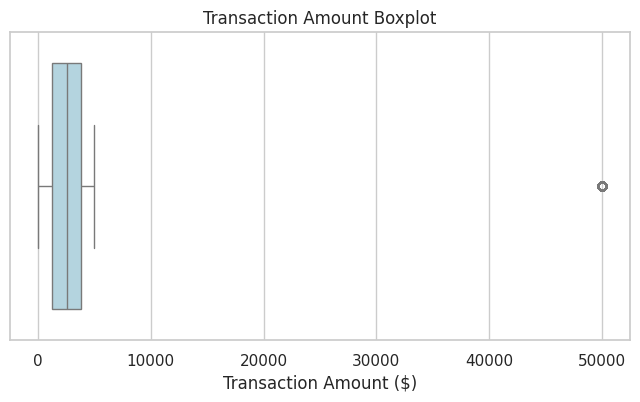

Transaction_Amount IQR Bounds -> Q1: 1270.55, Q3: 3787.24, Lower: -2504.48, Upper: 7562.27
Outliers Count: 508 (1.00%)


In [18]:
def amount_outliers(df):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df["Transaction_Amount"], color="lightblue")
    plt.title("Transaction Amount Boxplot")
    plt.xlabel("Transaction Amount ($)")
    show_plot()

    q1, q3, lower, upper = iqr_bounds(df["Transaction_Amount"])
    flagged = rows_outside(df, "Transaction_Amount", lower, upper)
    print(f"Transaction_Amount IQR Bounds -> Q1: {q1:.2f}, Q3: {q3:.2f}, "
          f"Lower: {lower:.2f}, Upper: {upper:.2f}")
    print(f"Outliers Count: {flagged.shape[0]} ({flagged.shape[0] / len(df) * 100:.2f}%)")


amount_outliers(df)

**What we see:** the rule flags **508 rows (1.00%)** above 7,562.27. All 508 equal exactly **49,997.80**, the column maximum, so they look like a cap or placeholder value rather than genuinely extreme purchases.

### Task 2B – Outliers in `Time_of_Transaction`

Time_of_Transaction IQR Bounds -> Lower: -13.00, Upper: 35.00
Outliers Count via IQR: 0


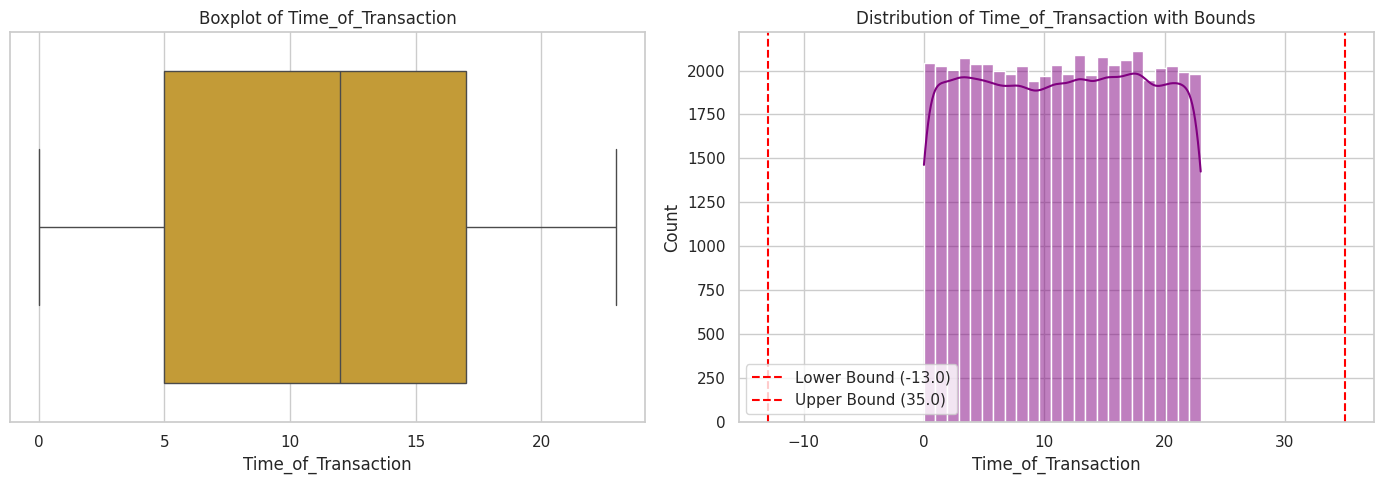

In [19]:
def task2b_time_outliers(df):
    _, _, lower, upper = iqr_bounds(df["Time_of_Transaction"].dropna())
    flagged = rows_outside(df, "Time_of_Transaction", lower, upper)
    print(f"Time_of_Transaction IQR Bounds -> Lower: {lower:.2f}, Upper: {upper:.2f}")
    print(f"Outliers Count via IQR: {flagged.shape[0]}")

    fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(x=df["Time_of_Transaction"], ax=left, color="goldenrod")
    left.set_title("Boxplot of Time_of_Transaction")

    sns.histplot(df["Time_of_Transaction"], bins=24, kde=True, ax=right, color="purple")
    right.axvline(lower, color="red", linestyle="--", label=f"Lower Bound ({lower:.1f})")
    right.axvline(upper, color="red", linestyle="--", label=f"Upper Bound ({upper:.1f})")
    right.set_title("Distribution of Time_of_Transaction with Bounds")
    right.legend()

    plt.tight_layout()
    show_plot()


task2b_time_outliers(df)

**What we see:** the fences (−13 to 35) lie far outside the possible 0–23 range, so there are **0 outliers**. Hours are close to uniformly distributed.

## 8. Task 3 – Common and Uncommon Values
The two most and two least frequent values per categorical column, and min / median / max for numeric columns.

In [20]:
def task3_common_and_rare(df):
    print("--- Most Common & Uncommon Categories per Feature ---")
    for column in CATEGORICAL_COLUMNS:
        frequency = df[column].value_counts(dropna=False)
        print(f"\nFeature: {column}")
        print(f"  Top Most Common: {frequency.head(2).to_dict()}")
        print(f"  Uncommon / Rare: {frequency.tail(2).to_dict()}")

    print("\n--- Common Ranges & Extremes for Numerical Attributes ---")
    for column in NUMERIC_SUMMARY_COLUMNS:
        print(f"{column} -> Min: {df[column].min()}, "
              f"Median: {df[column].median():.2f}, Max: {df[column].max()}")


task3_common_and_rare(df)

--- Most Common & Uncommon Categories per Feature ---

Feature: Transaction_Type
  Top Most Common: {'Bill Payment': 10340, 'Bank Transfer': 10276}
  Uncommon / Rare: {'POS Payment': 10126, 'Online Purchase': 10094}

Feature: Device_Used
  Top Most Common: {'Desktop': 15795, 'Mobile': 15614}
  Uncommon / Rare: {nan: 2473, 'Unknown Device': 1530}

Feature: Location
  Top Most Common: {'Boston': 6149, 'New York': 6110}
  Uncommon / Rare: {'San Francisco': 5985, nan: 2547}

Feature: Payment_Method
  Top Most Common: {'UPI': 11887, 'Debit Card': 11802}
  Uncommon / Rare: {nan: 2469, 'Invalid Method': 1530}

--- Common Ranges & Extremes for Numerical Attributes ---
Transaction_Amount -> Min: 5.03, Median: 2524.10, Max: 49997.8
Time_of_Transaction -> Min: 0.0, Median: 12.00, Max: 23.0
Account_Age -> Min: 1, Median: 60.00, Max: 119
Number_of_Transactions_Last_24H -> Min: 1, Median: 7.00, Max: 14


**What we see:** real categories are almost equally frequent. The genuinely rare entries are data-quality ones: missing values, `Unknown Device` and `Invalid Method` (both 1,530 rows). Items such as `POS Payment` only appear in the "rare" list because they are marginally less frequent than the leaders.

## 9. DBSCAN Anomaly Detection
**DBSCAN** groups points in dense regions and labels isolated points as noise (`-1`) – our anomalies. The base model uses four features with `eps = 0.8`, `min_samples = 15`.

In [21]:
def base_dbscan(df):
    clustered = run_dbscan(df, BASE_FEATURES, BASE_EPS, BASE_MIN_SAMPLES)
    print("Base DBSCAN Cluster Distribution:")
    print(clustered["Cluster"].value_counts())
    print(f"Total Base Noise/Anomalies (Cluster = -1): {(clustered['Cluster'] == -1).sum()}")
    return clustered


base_result = base_dbscan(df)

Base DBSCAN Cluster Distribution:
Cluster
 0    50492
 1      505
-1        3
Name: count, dtype: int64
Total Base Noise/Anomalies (Cluster = -1): 3


**What we see:** two dense clusters (50,492 and 505 points) and only **3** anomalies.

### Task 4 – Alternative Feature Set
Adds `Time_of_Transaction` and uses a slightly larger radius (`eps = 0.9`, `min_samples = 20`). We also compare the fraud rate inside and outside the anomaly group.

In [22]:
def task4_alternative_dbscan(df):
    clustered = run_dbscan(df, ALT_FEATURES, ALT_EPS, ALT_MIN_SAMPLES)

    print("--- Alternative DBSCAN Cluster Counts ---")
    print(clustered["Cluster"].value_counts())

    is_anomaly = clustered["Cluster"] == -1
    anomalies, normal = clustered[is_anomaly], clustered[~is_anomaly]

    print(f"\nAlternative DBSCAN Anomalies Count: {len(anomalies)} "
          f"({len(anomalies) / len(clustered) * 100:.2f}%)")
    print(f"Fraud Rate in Anomalies (Cluster = -1): {anomalies['Fraudulent'].mean() * 100:.2f}%")
    print(f"Fraud Rate in Normal Clusters: {normal['Fraudulent'].mean() * 100:.2f}%")

    print("\nSample Alternative Anomaly Records:")
    print(anomalies[ALT_FEATURES + ["Fraudulent"]].head(10).to_string())
    return clustered


def show_base_anomalies(base_result):
    print("Suspicious Base Anomaly Records (Head):")
    print(base_result[base_result["Cluster"] == -1].head())


alt_result = task4_alternative_dbscan(df)
show_base_anomalies(base_result)

--- Alternative DBSCAN Cluster Counts ---
Cluster
 0    50492
-1      470
 1       38
Name: count, dtype: int64

Alternative DBSCAN Anomalies Count: 470 (0.92%)
Fraud Rate in Anomalies (Cluster = -1): 6.38%
Fraud Rate in Normal Clusters: 4.91%

Sample Alternative Anomaly Records:
     Transaction_Amount  Time_of_Transaction  Previous_Fraudulent_Transactions  Account_Age  Number_of_Transactions_Last_24H  Fraudulent
166             49997.8                  3.0                                 3          108                                8           0
236             49997.8                  3.0                                 3          103                                6           0
245             49997.8                  1.0                                 3           78                                9           0
298             49997.8                 18.0                                 2           85                                2           0
317             49997.8           

**What we see:** **470 anomalies (0.92%)**, mostly rows with the 49,997.80 amount. The fraud rate is 6.38% in anomalies vs 4.91% elsewhere – in the expected direction, but with only 470 points the gap is not statistically significant (p ≈ 0.17).

## 10. Task 5 – Cluster and Anomaly Graphs
Left: base model (amount vs previous frauds). Right: alternative model (amount vs time). Dense points are sampled (3,000) for readability; anomalies are drawn in red.

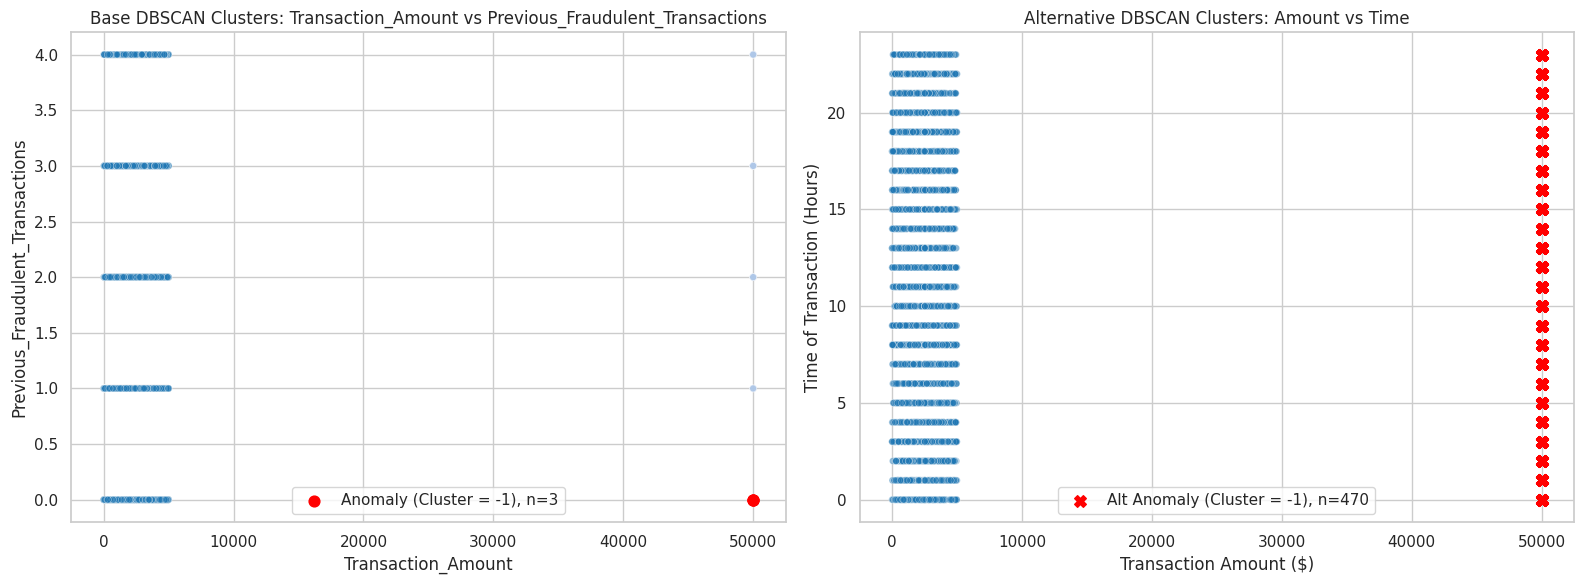

In [23]:
def draw_cluster_panel(ax, data, x_col, y_col, title, anomaly_marker, anomaly_size, anomaly_label):
    """Scatter of clustered points (sampled for speed) with anomalies overlaid in red."""
    dense = data[data["Cluster"] != -1]
    anomalies = data[data["Cluster"] == -1]
    shown = dense.sample(n=min(3000, len(dense)), random_state=SEED)

    sns.scatterplot(data=shown, x=x_col, y=y_col, hue="Cluster", palette="tab20",
                    alpha=0.5, s=25, ax=ax, legend=False)
    ax.scatter(anomalies[x_col], anomalies[y_col], c="red", marker=anomaly_marker,
               s=anomaly_size, label=f"{anomaly_label} (Cluster = -1), n={len(anomalies)}")
    ax.set_title(title)
    ax.legend()


def task5_cluster_graphs(base_result, alt_result):
    fig, (left, right) = plt.subplots(1, 2, figsize=(16, 6))

    # Left: base model - Amount vs Previous fraud count
    x_attr, y_attr = "Transaction_Amount", "Previous_Fraudulent_Transactions"
    draw_cluster_panel(left, base_result, x_attr, y_attr,
                       f"Base DBSCAN Clusters: {x_attr} vs {y_attr}",
                       anomaly_marker="o", anomaly_size=60, anomaly_label="Anomaly")
    left.set_xlabel(x_attr)
    left.set_ylabel(y_attr)

    # Right: alternative model - Amount vs Time of transaction
    draw_cluster_panel(right, alt_result, "Transaction_Amount", "Time_of_Transaction",
                       "Alternative DBSCAN Clusters: Amount vs Time",
                       anomaly_marker="X", anomaly_size=70, anomaly_label="Alt Anomaly")
    right.set_xlabel("Transaction Amount ($)")
    right.set_ylabel("Time of Transaction (Hours)")

    plt.tight_layout()
    show_plot()


task5_cluster_graphs(base_result, alt_result)

**What we see:** the anomalies sit in one vertical line at the maximum amount, which confirms the 49,997.80 cap is what DBSCAN is isolating – regardless of the hour or previous-fraud count.

## 11. Summary of Findings
* **Data quality:** ~5% missing in five columns, 881 exact duplicate rows, and 1,000 repeated `Transaction_ID` values.
* **Class balance:** only ~4.9% of transactions are fraud.
* **Payment method:** no significant relationship with fraud (chi-square p = 0.57).
* **Outliers:** amount is right-skewed (mean 2,996 vs median 2,524); 508 outliers are all the exact value 49,997.80. Time of transaction has no outliers and is roughly uniform.
* **DBSCAN:** 3 anomalies (base) and 470 (alternative), dominated by the capped amount. Their fraud rate is a little higher (6.38% vs 4.91%), but the difference is not statistically significant, so DBSCAN here flags *unusual records* rather than proving a fraud detector.